In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

import nltk

In [6]:
import pandas as pd
df = pd.read_csv("Reviews.csv")
df.head

<bound method NDFrame.head of             Id   ProductId          UserId                      ProfileName  \
0            1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1            2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2            3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3            4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4            5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   
...        ...         ...             ...                              ...   
568449  568450  B001EO7N10  A28KG5XORO54AY                 Lettie D. Carter   
568450  568451  B003S1WTCU  A3I8AFVPEE8KI5                        R. Sawyer   
568451  568452  B004I613EE  A121AA1GQV751Z                    pksd "pk_007"   
568452  568453  B004I613EE   A3IBEVCTXKNOH          Kathy A. Welch "katwel"   
568453  568454  B001LR2CU2  A3LGQPJCZVL9UC                         srfell17   

        HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                          1                       1      5  1303862400   
1                          0                       0      1  1346976000   
2                          1                       1      4  1219017600   
3                          3                       3      2  1307923200   
4                          0                       0      5  1350777600   
...                      ...                     ...    ...         ...   
568449                     0                       0      5  1299628800   
568450                     0                       0      2  1331251200   
568451                     2                       2      5  1329782400   
568452                     1                       1      5  1331596800   
568453                     0                       0      5  1338422400   

                                   Summary  \
0                    Good Quality Dog Food   
1                        Not as Advertised   
2                    "Delight" says it all   
3                           Cough Medicine   
4                              Great taffy   
...                                    ...   
568449                 Will not do without   
568450                        disappointed   
568451            Perfect for our maltipoo   
568452  Favorite Training and reward treat   
568453                         Great Honey   

                                                     Text  
0       I have bought several of the Vitality canned d...  
1       Product arrived labeled as Jumbo Salted Peanut...  
2       This is a confection that has been around a fe...  
3       If you are looking for the secret ingredient i...  
4       Great taffy at a great price.  There was a wid...  
...                                                   ...  
568449  Great for sesame chicken..this is a good if no...  
568450  I'm disappointed with the flavor. The chocolat...  
568451  These stars are small, so you can give 10-15 o...  
568452  These are the BEST treats for training and rew...  
568453  I am very satisfied ,product is as advertised,...  

[568454 rows x 10 columns]>

In [7]:
df['Text'].values[1]

'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".'

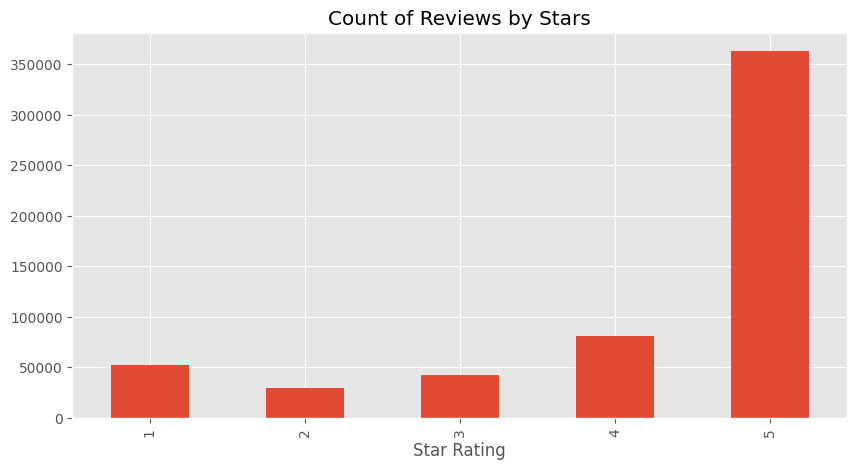

In [8]:
ax = df['Score'].value_counts().sort_index().plot(kind = 'bar', title = 'Count of Reviews by Stars', figsize = (10,5))
ax.set_xlabel('Star Rating')
plt.show()

In [9]:
df = df[['Text', 'Score']].dropna()

df = df[df['Score'] != 3]

df['Sentiment'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)

positive_df = df[df['Sentiment'] == 1]
negative_df = df[df['Sentiment'] == 0]

sample_size = min(len(positive_df), len(negative_df), 50000)

positive_sample = positive_df.sample(sample_size, random_state=42)
negative_sample = negative_df.sample(sample_size, random_state=42)

df = pd.concat([positive_sample, negative_sample])
df = df.sample(frac=1, random_state=42)

print(df['Sentiment'].value_counts())

Sentiment
0    50000
1    50000
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['Text'] = df['Text'].apply(clean_text)

In [12]:
x = df['Text']
y = df["Sentiment"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)


In [13]:
vectorizer = TfidfVectorizer(max_features = 15000, ngram_range = (1,3))

x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

In [14]:
model = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
model.fit(x_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [15]:
y_pred = model.predict(x_test_vec)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

Accuracy: 0.9233
              precision    recall  f1-score   support

           0       0.92      0.93      0.92     10078
           1       0.93      0.92      0.92      9922

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000



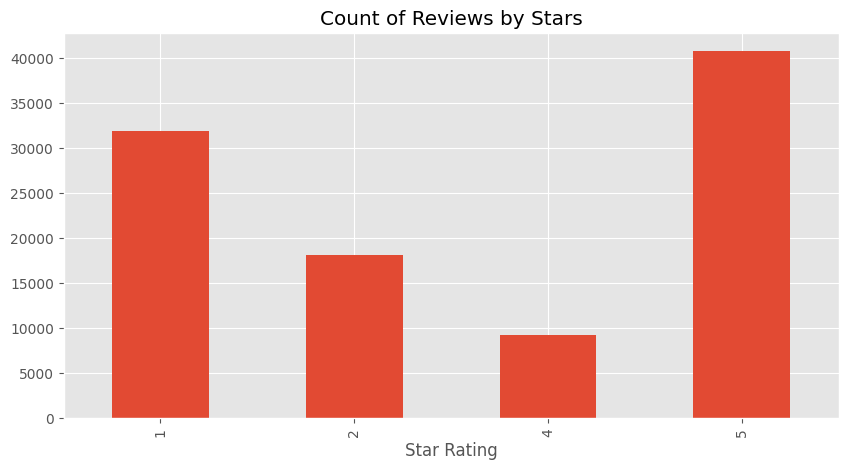

In [18]:
ax = df['Score'].value_counts().sort_index().plot(kind = 'bar', title = 'Count of Reviews by Stars', figsize = (10,5))
ax.set_xlabel('Star Rating')
plt.show()

In [20]:
def predict_sentiment(review):

    review_vec = vectorizer.transform([review])

    prediction = model.predict(review_vec)[0]
    probabilities = model.predict_proba(review_vec)[0]

    negative_score = probabilities[0]
    positive_score = probabilities[1]

    sentiment = "Positive" if prediction == 1 else "Negative"

    return sentiment, positive_score, negative_score


review = input("Enter your review: ")
result = predict_sentiment(review)

print(f"Sentiment: {result[0]}, Positive Score: {result[1]:.3f}, Negative Score: {result[2]:.3f}")

Enter your review: the quality of product was very good
Sentiment: Positive, Positive Score: 0.811, Negative Score: 0.189
